$$ \Large{\textbf{DNA Sequence Classification: Machine Learning and Digital Signal Processing}} $$   
$$ \large{\textbf{Part IIa: Matching of Fungi DNA sub-sequences with cross-correlation.}} $$ <br>

<br>
$$ \small{\textbf{Dr. Stéphane DEDIEU, Fall-Winter 2022. }} $$

<br>


# Introduction  <a class="anchor" id="chapter1"></a>


<span style="color:#006699"> This notebook is a preliminary section to Part IIb: Supervised Classification of Fungi DNA sequences.  <br> 
The simple approach ML-FFT succesfully tested in Part I with the Bird-Fish-Mammal dataset, is not effective with the Fungi dataset. It was tested with NFFT=1024 since the length of a few DNA sequence is lower than 2048.  <br>
We introduce a simple "soft" alignment method based on splitting DNA sequences in NFFT long frames, and computing crosscorrelation. <br>
<br> Note that the ML-DSP approach by Gurjit S. Randhawa [1], was precisely developped for preventing the use of "heavy" DNA sequrnces alignement method.<br> At that point, any alignment strategy makes sense:
- <span style="color:#006699">  if it is fast
- <span style="color:#006699">  if final classification accuracy is significantly higher than reference ML-DSP accuracy, 89.3% with the Fungi dataset in Gurjit S. Randhawa [1]. In similar conditions: optimization of hyperparameters, 10-folds cross-validation. <br>     

##  Dataset

<span style="color:#006699">  <b>Supervised Classification Fungi Dataset.</b> DNA sequences are in the following folders: <b> Basidiomycota, Pezizomycotina, Saccharomycotina.</b> <br>
<span style="color:#006699">  This data <b>is not used</b> for DNA sequences alignment purposes. 
<br>
    
| Dataset for classification | Number of DNA sequences |
|  ---    |     ---   |
|  Basidiomycota |    30|
|  Pezizomycotina |   90 |
|  Saccharomycotina | 104  |
  
<br>

<span style="color:#006699">  **Alignment Dataset:**  we collected an independant fungi DNA sequence data set from the NCIB.  
    They are stored in folders: <b> A_Basidiomycota, A_Pezizomycotina, A_Saccharomycotina.</b> 
    Each folder contains 20 sequences, with TCAG nucleotides, except folder A_Pezizomycotina. Apparently we did not import full mitochondrial genome sequences only. We had to get rid of 4 sequences with nucleotides K, M, or Y.  
<br>    
    
| Alignment Datasets | Number of DNA sequences |
|  ---    |     ---   |
|  A_Basidiomycota |    20|
|  A_Pezizomycotina |   16 |
|  A_Saccharomycotina |   20  |

<br>
<span style="color:#006699">  In spite of a relative low number of DNA sequences in the alignment dataset, the identification  of an effective reference frame in each phylum was possible.  

## Principle of the Soft Alignment Algorithm

<span style="color:#006699">  In general an alignement process is intended to align sequences different in length. More information can be found in [2] where the authors present (we cite) <i> the utilization of progressive alignment principle for positional adjustment of a set of genomic signals with different lengths.The new method of multiple alignment of signals based on dynamic time-warping is tested for the purpose of evaluating the similarity of different length genes in phylogenetic studies.</i> <br>
<br>
<span style="color:#006699"> Instead of considering full DNA sequences, we stick to the idea of working with short frames, NFFT= 1024 like we did in Part I. <br> In this case, the problem is more about splitting each DNA sequence into short frames, and selecting frames that share common features to a certain extent, with a reference frame that is to be defined. The process is based on cross-correlation. <br> By comparison with reference frames, every DNA sequence NFFT optimal frames are selected, based on the maximization of the cross-correlation. Visually there is nothing noticeable, it does not guarantee that we "really" align DNA frames.  Just that there is some common features in the frames we compare. <br>
We selected the name: "soft alignment", because in practise it does not really look like a common alignment technique. 

<span style="color:#006699"> Basically the process consists of:  <br>
    (1) selecting a reference NFFT frame in each phylum <br>
    (2) selecting optimum NFFT frames in all DNA sequences, optimal meaning: the frames that align best with reference frames.  
    (3) compute FFT of optimal NFFT frames. <br>
    (4) Feed Machine Learning algorithms with FFT spectrums magnitude (or magnitude + phase).  
 
<span style="color:#006699"> Contrarily to the simple ML-FFT method where we selected the first NFFT points of each DNA sequence, in the ML-FFT Soft Align method, NFFT frames are selected based on the maximum correlation with the 3 Fungi reference frames defined in this work. <b><i>The process is a pre-classifier.</i></b> <br> The method is relatively fast, at least for the datasets and the length of DNA sequences (genomic signals) considered here.  

###   Detailed method.

<span style="color:#006699"> Note: <br> 
    - "NFFT frame(s)" means "frame(s) of length NFFT points (or bp)". <br>
    - "st" is the step size when splitting DNA sequences. In general we use "st"= NFFT (no overlap), "st"= NFFT//2 or NFFT//4...
<br>
<br>
<span style="color:#006699"> <b> Step I: identifying reference NFFT frames </b> <br>
<br>
    In each "alignment" phylum folder: <b>A_Basidiomycota, A_Pezizomycotina, A_Saccharomycotina</b>: <br>
<br>
(1) a reference DNA sequence is selected at random and split into NFFT frames: $F_{k_1}$, $F_{k_2}$, $F_{k_3}$,... with step $st$. <br>
(2) for selecting a reference frame k_opt, all other DNA squences $G^{[i]}$ in the phyllum <b><i>Mat_DNA</i></b> are split into NFFT frames: $G^{[i]}_{j_1}$, $G^{[i]}_{j_2}$, $G^{[i]}_{j_3}$, $G^{[i]}_{j_4}$... with step st. Note that for each DNA sequence $i$, the number of NFFT frames $i_j$ is not constant ! Since DNA seuqnces are different in length. This aspect have no consequences for the method.<br> (3) We compute the crosscorrelation for all pairs: $[F_{k_l},G^{[i]}_{j_3}]$, $\; \; i=1,2,....i_{max}$  where $i_{max}$ number of DNA sequences G. And for each pair, <b><i>we store the maximum of the crosscorrelation in a matrix $CC\_max[i,k_l]$. </i></b>. Dimensions: number of DNA sequences x number of NFFT frames in reference DNA sequence.  <br>
(4) in the end, we select the reference DNA NFFT frame $F_{k_l}$ that maximizes the average (or sum) of all max of crosscorrelation, i.e. the k index that maximizes the sum of all columns of matrix $CC\_max[i,k_l]$. For each $k= k_l$  we compute:  $\sum_{i=0}^{i_{max}}CC\_max[i,k_l]$ and select frame $F_{k_l}$ linked to the maximum sum, $F_{k_{opt}}$.     
<br>
<br>
For this particular Fungi classification problem, we end up with 3 reference NFFT frames:  $B,P,S$  (Basidiomycota, Pezizomycotina, Saccharomycotina). <br>   
   
<br>    
<span style="color:#006699">  <b> Step II: identification of optimal NFFT frames in all DNA sequences.</b>   <br>
    
(1) We determine optimal NFFT frames in each DNA sequences by comparison with the reference frames $B, P, S$ as shown in the figure below.<br>(2) We measure the cross-correlation of all frames in all DNA sequences with the reference frames and select the ones that align best with reference frames: i.e maximize cross-correlation. <br>(3) This process will be applied <b><i>to any unknown genome/DNA sequence</i></b>, particularly DNA sequences in the Fungi classification dataset used in Part IIb.  
<br>     
<br> 

<img src="Fungi_Alignment.png" alt="drawing" width="950"/>  

<span style="color:#006699">


<center><i><b> Random DNA sequence: process for selecting <b>optimal</b> NFFT frame after comparison (cross-correlation) with 3 reference frames $B,P,S$.</b></i></center>  

 Note that an optimal frame in a phylum, will not necessarily optimally align with the reference frame in that phylum. <b><i>Our soft alignment method is an imperfect pre-classification process</i></b>. But it proves sufficient to significantly improve the accuracy in the supervised classification process (Part IIb).<br>     
    
<b>Remarks </b>:
        
- This Notebook is short, results and Conclusions are at the end.  
- The soft alignment method is designed to stick to our short FFT one-sided spectrums with NFFT=1024. Spectrum magnitude only (512 points) or Magnitude+Phase (1024 points).
- By applying soft alignment to various phylums, we hope to extract a common set of nucleotide subsequences in that particular phylum, that helps with proper classification of various species.  
- Reducing the value of parameter <i>st</i> may help with refining the selection of reference NFFT frames. But it may become computationnal intensive, with a high number of phylums (insect class), or/and if we increase the number of DNA sequences in the alignment dataset. 
- The value of parameter <i>st</i> has an impact on final classification accuracy.   

##  Computation Time


<span style="color:#006699"> Processor: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz <br>
NFFT=1024,  $st$:  NFFT (no step, no overlap), NFFT//2, NFFT//4. <br> 
Computation time is dominated by Step I: identifying the reference frames. <br>
Reference frame computation time depends on the length of the reference DNA sequences, and DNA sequences in each phylum. Each time we divide $st$ by 2, we roughly increase computation time by a factor 4. <br> Results are shown below, in seconds.    

|        | Number of DNA sequences |  st=NFFT (s)  |   st=NFFT//2  (s) |   st=NFFT//4  (s) |  
|  ---    |     ---                | ---       |   ---         |  ---         |  
|  A_Basidiomycota |    20         |      34     |    133          |      597        |
|  A_Pezizomycotina |   16         |      13     |  47             |      248        |
|  A_Saccharomycotina |   20       |      15     |   57            |      265        |







## References


[1] "ML-DSP: Machine Learning with Digital Signal Processing for ultrafast, accurate, and scalable genome classification at all taxonomic levels" by Gurjit S. Randhawa , Kathleen A. Hill and Lila Kari. Department of Computer Science, University of Western Ontario, London, ON, Canada. Randhawa et al. BMC Genomics (2019) 20:267 https://doi.org/10.1186/s12864-019-5571-y

[2] Helena Skutkova, Martin Vitek, Karel Sedlar, Ivo Provaznik, Progressive alignment of genomic signals by multiple dynamic time warping, Journal of Theoretical Biology, Volume 385, 2015, Pages 20-30, ISSN 0022-5193,
https://doi.org/10.1016/j.jtbi.2015.08.007.


##  Required libraries

In [1]:
#--------------------------------------------
# Notebook wide presentation
#--------------------------------------------
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

#-------  For centering figures 
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [2]:
import time
import random
from scipy import signal
from skimage import util

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import string
import screed # A Python library for reading FASTA and FASQ file format.
def readFastaFile(inputfile):
    """
    Reads and returns file as FASTA format with special characters removed.
    """
    with screed.open(inputfile) as seqfile:
        for read in seqfile:
            seq = read.sequence
    return seq

#  Importing and converting data 

<span style="color:#006699">  We do not elaborate, the process is similar to Part I.  <br>
We just import data from the Alignment dataset.  <br> 
We use the PP (Purine/Pyrimidine) numerical coding which gives best results in the paper by Gurjit S. Randhawa [1].    .        

In [5]:
import glob
import re
import os

fungi_folder= "MLDSP-master/DataBase/Fungi"   # Your path here 

fungi_ABasidiomycota = glob.glob(fungi_folder + '/A_Basidiomycota/' + 'A*.txt') # 
fungi_APezizomycotina = glob.glob(fungi_folder + '/A_Pezizomycotina/' + 'A*.txt') 
fungi_ASaccharomycotina = glob.glob(fungi_folder + '/A_Saccharomycotina/' + 'A*.txt') 

fungi_AB= []
fungi_AP= []
fungi_AS= []

for fname in fungi_ABasidiomycota:
    fungi_AB.append(readFastaFile(fname))
    
for fname in fungi_APezizomycotina:
    fungi_AP.append(readFastaFile(fname))

for fname in fungi_ASaccharomycotina:
    fungi_AS.append(readFastaFile(fname))

print(type(fungi_AB))
print(np.shape(fungi_AB), np.shape(fungi_AP), np.shape(fungi_AS))
print(len(fungi_AB[0]))
print(len(fungi_AB[1]))
print(len(fungi_AB[2]))
print(len(fungi_AB[3]))
print(fungi_AB[1][0:20])

<class 'list'>
(20,) (16,) (20,)
78447
189696
54177
70059
GTGAGGTTTATAAATAGATG


In [7]:
#----------
# At the moment and for validation purposes, we keep all conversion steps separated. 
#---------- 
def conversion_DNA_str(X,Y,instr, outstr):
        for j in range(0,len(X)):
            Y.append(X[j].translate({ord(x): y for (x, y) in zip(instr, outstr)}))        
        return Y
#----------    
def conversion_DNA_num(X,Y):
        for j in range(0,len(X)):
            Y.append([int(x) for x in str(X[j])])     
        return Y

In [8]:
#------------------
#  Testing various types of numerical representations. 
#------------------
instr = "TCAG"
#outstr = "0010"; cornr= 0.5    #  Just A representation 
#outstr = "1234"    #  Integer representation I
#outstr = "0123";  cornr= 1.5     #  Integer representation II
outstr = "2200"; cornr=1    #  PP representation  [T,C]= 1, [A,G]= -1  Must substract 1 in all DNA sequences matrices  ! 
#---------
DNA_AB=[]
DNA_AP=[]
DNA_AS=[]
#---------
DNA_AB=conversion_DNA_str(fungi_AB, DNA_AB,instr, outstr)
DNA_AP=conversion_DNA_str(fungi_AP, DNA_AP,instr, outstr)
DNA_AS=conversion_DNA_str(fungi_AS, DNA_AS,instr, outstr)
#--------- 
AB=[]
AP=[]
AS=[]
#---------
AB=conversion_DNA_num(DNA_AB,AB)
AP=conversion_DNA_num(DNA_AP,AP)
AS=conversion_DNA_num(DNA_AS,AS)

In [9]:
Mat_DNA_AB = np.array([np.array(x) for x in AB], dtype=object)  -cornr 
Mat_DNA_AP = np.array([np.array(x) for x in AP], dtype=object)  -cornr
Mat_DNA_AS = np.array([np.array(x) for x in AS], dtype=object)  -cornr 

In [10]:
lenkb= np.empty(len(Mat_DNA_AB)).astype(int) 
lenkp= np.empty(len(Mat_DNA_AP)).astype(int) 
lenks= np.empty(len(Mat_DNA_AS)).astype(int) 

for k in range(len(Mat_DNA_AB)) :
    lenkb[k]=len(Mat_DNA_AB[k])
    
for k in range(len(Mat_DNA_AP)) :
    lenkp[k]=len(Mat_DNA_AP[k])

for k in range(len(Mat_DNA_AS)) :
    lenks[k]=len(Mat_DNA_AS[k])

In [11]:
min_b = pd.Series(lenkb).min() 
min_p = pd.Series(lenkp).min() 
min_s = pd.Series(lenks).min() 
max_b = pd.Series(lenkb).max() 
max_p = pd.Series(lenkp).max() 
max_s = pd.Series(lenks).max() 
print('Min length DNA seq. B,P,S: ',min_b, min_p, min_s)
print('Max length DNA seq. B,P,S: ',max_b, max_p, max_s)

Min length DNA seq. B,P,S:  31825 28301 18844
Max length DNA seq. B,P,S:  189696 191042 85779


In [12]:
id_min_p = pd.Series(lenkp).idxmin() 
id_min_p

4

In [13]:
len(Mat_DNA_AP[4])

28301

# Cross-correlation function

<br>
<span style="color:#006699">In general, when dealing with Digital Signal Processing algorithms, Python is rather slow, compared with Matlab for example. <br> Selecting the fastest option for cross correlation is particularly critical. <br>
We could use: <code>signal.correlate(frames[i], frameRef, mode='same', method='auto'))</code>. It either returns a vector 2*NFFT or NFFT long depending on options. The fft, ifft based method is known to be faster.<br>
<b><i> Given the size of the problem and the number of cross-correlation calculations, we selected the fft based method.</i></b><br> The method returns a NFFT long cross-correlation vector. Delay= 0 at NFFT//2.  

In [14]:
import numpy as np
from numpy.fft import fft, ifft, fft2, ifft2, fftshift

def cross_correlation_using_fft(x, y):
    f1 = fft(x)
    f2 = fft(np.flipud(y))
    cc = np.real(ifft(f1 * f2))
    return fftshift(cc)
    #return cc
# shift < 0 means that y starts 'shift' time steps before x # shift > 0 means that y starts 'shift' time steps after x
#def compute_shift(x, y):
#    assert len(x) == len(y)
#    c = cross_correlation_using_fft(x, y)
#    assert len(c) == len(x)
#    zero_index = int(len(x) / 2) - 1
#    shift = zero_index - np.argmax(c)
#    return shift

### Visualisation of Cross-Correlation

<span style="color:#006699"> We select a DNA sequence, here: Mat_DNA_AP[4] and the first 1024 nucleotides. <br> Section under construction. 

# DNA sequences Alignment

## Identification of Reference Frames

In [46]:
def DNA_frames_alignment_v1(Mat_DNA, DNA_ref, id_seq_ref, seq_length, step_l):

    eps=1.e-3
    frames_ref = util.view_as_windows(DNA_ref, window_shape=(seq_length,), step=step_l)   #  split reference sequence in multiple frames
    print('Number x Size of reference frames under test', frames_ref.shape)
    align_start= time.time()
    print('Running')
    cross_max=np.zeros([len(Mat_DNA),len(frames_ref)]).astype(float) 
    
    for k in range(len(frames_ref))    :  
        k_start= time.time()      
        frameRef=frames_ref[k] # for each possible reference frame        
        for j in [x for x in range(len(Mat_DNA)) if x != id_seq_ref]:
        #-----
            frames = util.view_as_windows(Mat_DNA[j], window_shape=(seq_length,), step=step_l)   #  AVERAGING FULL LENGTH  GOOD !!  
            max_cross_corr=np.empty(len(frames)).astype(float)
        #--------
            for i in range(len(frames)):               
                    #max_cross_corr[i] = np.max(signal.correlate(frames[i], frameRef, mode='same', method='auto')) 
                    max_cross_corr[i] = np.max(cross_correlation_using_fft(frames[i], frameRef)) + eps*np.random.uniform(0, 1)                                         
      
            idx_max = pd.Series(max_cross_corr).idxmax() # we keep the max, for defining optimal reference frame
            cross_max[j,k]= max_cross_corr[idx_max]      # For each reference frame [k] we store, optimal frame for each DNA sequence [j] 
    k_opt=pd.Series(sum(cross_max)).idxmax()
    print('Reference frame in ref. DNA sequence: k_opt=',k_opt)
    Ref_Frame= frames_ref[k_opt]
    align_end=time.time()    
    print(f'Alignment computing time (s) {align_end - align_start:.2f}') 
    return k_opt, Ref_Frame

In [60]:
seq_length=1024
step_l=seq_length//4 # seq_length//2, seq_length//4,  ...overlap when sliding window/frame on DNA sequence under test

<span style="color:#006699"> The 3 reference frames for phylums will be selected in 3 DNA sequences selected at random in each phylum. <br>
    For investigating the impact of various parameters like NFFT or the step=NFFT//4, NFFT//8 ... all calculations <b> are run with the first indices generated at random </b> when we started the process of selecting the reference DNA sequence.      

In [61]:
print("Basidiomycota DNA sequences frames alignment")

#id_seq_ref= random.randint(0,len(Mat_DNA_AB)) # select ref. DNA sequence at random
id_seq_ref= 10   # first index generated at random. 
DNA_ref=Mat_DNA_AB[id_seq_ref]  
print('index of reference DNA sequence:',id_seq_ref)

kb_opt, Ref_Frame_AB = DNA_frames_alignment_v1(Mat_DNA_AB, DNA_ref , id_seq_ref, seq_length, step_l)

Basidiomycota DNA sequences frames alignment
index of reference DNA sequence: 10
Number x Size of reference frames under test (186, 1024)
Running
Reference frame in ref. DNA sequence: k_opt= 17
Alignment computing time (s) 597.50


In [62]:
print("Pezizomycotina DNA sequences frames alignment")

#id_seq_ref= random.randint(0,len(Mat_DNA_AP))   # select ref. DNA sequence at random
id_seq_ref=4    # first index generated at random. 
DNA_ref=Mat_DNA_AP[id_seq_ref]    
print('index of reference DNA sequence:',id_seq_ref)

kp_opt, Ref_Frame_AP = DNA_frames_alignment_v1(Mat_DNA_AP, DNA_ref, id_seq_ref, seq_length, step_l)

Pezizomycotina DNA sequences frames alignment
index of reference DNA sequence: 4
Number x Size of reference frames under test (107, 1024)
Running
Reference frame in ref. DNA sequence: k_opt= 82
Alignment computing time (s) 248.19


In [63]:
print("Saccharomycotina DNA sequences frames alignment")

#id_seq_ref= random.randint(0,len(Mat_DNA_AS))  # select ref. DNA sequence at random
id_seq_ref=12
DNA_ref=Mat_DNA_AS[id_seq_ref]
print('index of reference DNA sequence:',id_seq_ref)
#ks_opt, Ref_Frame_AS = DNA_frames_alignment_v2(Mat_S, DNA_ref, Ref_Frame_AP, seq_length, step_l)
ks_opt, Ref_Frame_AS = DNA_frames_alignment_v1(Mat_DNA_AS, DNA_ref, id_seq_ref, seq_length, step_l)

Saccharomycotina DNA sequences frames alignment
index of reference DNA sequence: 12
Number x Size of reference frames under test (154, 1024)
Running
Reference frame in ref. DNA sequence: k_opt= 137
Alignment computing time (s) 265.65


<span style="color:#006699"> The 3 references frames are stored in array <b>Ref_Frame</b>. 

In [64]:
Ref_Frame= np.stack((Ref_Frame_AB, Ref_Frame_AP, Ref_Frame_AS), axis=0)

###  Aligning DNA sequences with reference frames

 

<span style="color:#006699"> Selection of the optimal NFFT frame in each DNA sequence.
<span style="color:#006699">  Function for determining best alignment of all DNA sequences with the 3 reference frames. And selecting optimal frame in each DNA sequence.  
    We verify that optimal frames selected 
    The process is applied to the classification dataset.

In [282]:
def DNA_frames_alignment_v10(Mat_DNA, Ref_Frame, seq_length, step_l):

    align_start= time.time()
    print('Running')
    eps=1e-6;
    Optimal_Frame=np.empty([len(Mat_DNA), seq_length ]).astype(float) 
    Optimal_k=np.empty(len(Mat_DNA)).astype(float) 
    #-----------------------------------------
    for j in range(len(Mat_DNA)):   # we took a frame in Mat_DNA[id_seq_ref] as a REFERENCE
    #-----
        frames = util.view_as_windows(Mat_DNA[j], window_shape=(seq_length,), step=step_l)   #  AVERAGING FULL LENGTH  GOOD !!  
        max_cross_corr=np.empty([len(frames),len(Ref_Frame)]).astype(float)
    #--------
        for i in range(len(frames)):

                for k in range(len(Ref_Frame)) :
                    frameRef=Ref_Frame[k] # for each possible reference frame 
                    max_cross_corr[i,k] = eps*np.random.uniform(0, 1) + \
                                        np.max(cross_correlation_using_fft(frames[i], frameRef)) 

        indices = np.where(max_cross_corr == max_cross_corr.max())
        Optimal_Frame[j]= frames[indices[0]]
        Optimal_k[j]=indices[1]
        
    align_end=time.time()    
    print(f'Alignment computing time (s) {align_end - align_start:.2f}') 

    return Optimal_Frame, Optimal_k

<b>Basidomycota</b>

In [283]:
Optimal_Frame_AB_Align, Optim_kb =DNA_frames_alignment_v10(Mat_DNA_AB, Ref_Frame, seq_length, step_l)

Running
Alignment computing time (s) 11.30


<b>Pezizomycotina</b> 

In [284]:
Optimal_Frame_AP_Align, Optim_kp =DNA_frames_alignment_v10(Mat_DNA_AP, Ref_Frame, seq_length, step_l)

Running
Alignment computing time (s) 8.54


<b>Saccharomycotina</b>

In [285]:
Optimal_Frame_AS_Align, Optim_ks =DNA_frames_alignment_v10(Mat_DNA_AS, Ref_Frame, seq_length, step_l)

Running
Alignment computing time (s) 8.59


# Results


<span style="color:#006699"> We plot alignment results: 

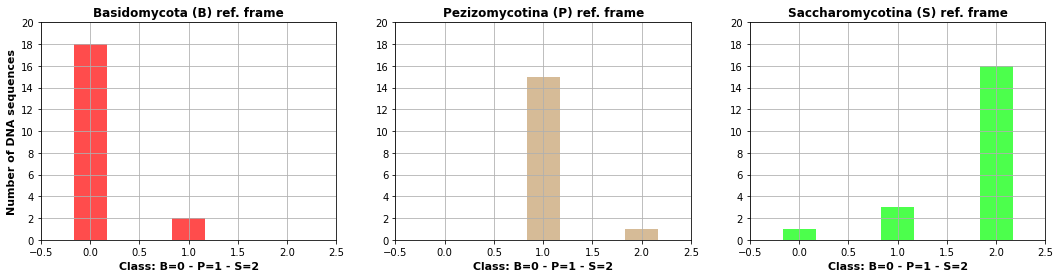

In [286]:
fig, axs = plt.subplots(1,3, figsize=(18,4))

# Fixing bin edges
HIST_BINS = np.linspace(-0.5, 2.5,10)
custom_ticks = np.linspace(0, 20, 11, dtype=int)

axs[0].hist(Optim_kb, HIST_BINS,  color='red', alpha=0.7)  
axs[0].set_xlim([-0.5,2.5])
axs[0].set_ylim([0,20])
axs[0].set_xlabel('Class: B=0 - P=1 - S=2', fontsize=11, weight='bold' )
axs[0].set_ylabel('Number of DNA sequences', fontsize=11, weight='bold' )
axs[0].set_title('Basidomycota (B) ref. frame', fontsize=12, weight='bold' )
axs[0].set_yticks(custom_ticks)
axs[0].grid()

axs[1].hist(Optim_kp,  HIST_BINS,  color='tan', alpha=0.9)         
            #histtype='bar', label='Pezizomycotina',   alpha=0.7, rwidth=1)
axs[1].set_xlim([-0.5,2.5])
axs[1].set_ylim([0,20])
axs[1].set_xlabel('Class: B=0 - P=1 - S=2', fontsize=11, weight='bold' )
axs[1].set_title('Pezizomycotina (P) ref. frame', fontsize=12, weight='bold' )
axs[1].set_yticks(custom_ticks)
axs[1].grid()

axs[2].hist(Optim_ks,  HIST_BINS,  color='lime', alpha=0.7) 
            #color='lime', histtype='bar', label='Saccharomycotina',  alpha=0.7, rwidth=1) 
axs[2].set_xlim([-0.5,2.5])
axs[2].set_ylim([0,20])
axs[2].set_xlabel('Class: B=0 - P=1 - S=2', fontsize=11, weight='bold' )
axs[2].set_title('Saccharomycotina (S) ref. frame', fontsize=12, weight='bold' )
axs[2].set_yticks(custom_ticks)
axs[2].grid()

#plt.hist(Optim_ks) 
plt.show()

#### Alignment:           

|                   | Ref. Basidomycota  | Ref.  Pezizomycotina  |  Ref. Saccharomycotina    | Total # of DNA sequences |
| ---               |    ---        |      ---         |     ---    |  ---  |         
| A_Basidomycota      |    18         |       2          |        0             |     20    |
| A_Pezizomycotina    |    0          |      15          |        1             |     16    |
| A_Saccharomycotina  |    1          |       3          |        16            |     20    |

<br>
<br>
<span style="color:#006699"> <b> How to read this table ? </b> <br>
Let's consider the first row: of all 20 Basidomycota DNA sequences from the Alignment dataset, 18 optimal frames aligned with Basidomycota reference frame, and 2 optimal frames aligned with Pezizomycotina reference frame.
The alignment process is a classifier*. The table is a confusion matrix. Statistics, Accuracy, are left as an exercise. <br>
<br>
In this preliminary study, in spite of the number of false positives and false negatives, we will deem the 3 identified reference frames <b>"acceptable"</b>. And we save them in a npy file for processing future Fungi DNA sequences data classification (Part IIb). We will see that their use is sufficient for boosting Fungi ML classification accuracy.      

<span style="color:#006699"> *We will say "pre-classifier". We still have to classify Fungi genomes based on magnitude and phase of their FFT spectrums using ML algorithms.

In [287]:
###np.save('BPS_PP_RefFrame_1024_d4_v10.npy', Ref_Frame)    # save the 3 reference frames in a .npy file. 

# Conclusions 

<span style="color:#006699"> 
We developped a soft alignment method for selecting:<br> 
    
- a reference NFFT frame in each phylum.. 
- optimal NFFT frames for all DNA sequences, by "aligning" them with reference NFFT frames. <br>

<br>
    
- The soft alignment method is simple, relatively fast. It constitutes a pre-classifier that was tested here with DNA sequences <b><i>in the alignment dataset</i></b>. 
- The pre-classifier has some level of accuracy, that depends on parameter step_l. Statistics regarding the accuracy of the pre-classifier are left as an exercise.
- The selection of a random reference DNA sequence at the beginning of the process did not seem to have a strong influence on the final result. As long as it is not a very short sequence: 1600 bp for example.<br>
<br>

In Part IIb, we work with the Fungi <b><i>classification dataset</i></b>. Before computing FFT spectrums, we will select optimal NFFT frames in each DNA sequence, by applying Step II in this Notebook.      